# Imports

In [1]:
import geopandas as gpd
import polars as pl
import pandas as pd
import numpy as np
from pathlib import Path
from skrub import TableReport

# I. Max depth


In [2]:
import xarray as xr
# import xclim.indices

# Set xarray to use HTML for displaying outputs
from pathlib import Path
nc_file_path = Path("../cama_flood/out/my_test_simulation") / "o_maxdph1980.nc"
# Open the NetCDF file
ds = xr.open_dataset(nc_file_path)

# Display dataset information
print("Dataset information:")

print("\n" + "="*50)
print("Variable information:")
print(ds.data_vars)

print("\n" + "="*50)
print("Coordinates:")
print(ds.coords)


Dataset information:

Variable information:
Data variables:
    maxdph   (lon, lat, time) float32 25MB ...

Coordinates:
Coordinates:
  * lon      (lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * time     (time) datetime64[ns] 48B 1980-01-01 1980-01-02 ... 1980-01-06


In [3]:
ds

<xarray.Dataset> Size: 25MB
Dimensions:  (lon: 1440, lat: 720, time: 6)
Coordinates:
  * lon      (lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * time     (time) datetime64[ns] 48B 1980-01-01 1980-01-02 ... 1980-01-06
Data variables:
    maxdph   (lon, lat, time) float32 25MB ...

In [4]:
maxdph = ds["maxdph"]  # or whatever the variable name is

# # 2. (optional) require at least 360 valid days per year
# valid_counts = runoff.groupby("time.year").count(dim="time")
# mask = valid_counts > 360

# Annual max runoff
yearly_max = maxdph.groupby("time.year").max(dim="time") #.where(mask)


In [5]:
yearly_max

<xarray.DataArray 'maxdph' (lon: 1440, lat: 720, year: 1)> Size: 4MB
array([[[1.e+20],
        [1.e+20],
        [1.e+20],
        ...,
        [1.e+20],
        [1.e+20],
        [1.e+20]],

       [[1.e+20],
        [1.e+20],
        [1.e+20],
        ...,
        [1.e+20],
        [1.e+20],
        [1.e+20]],

       [[1.e+20],
        [1.e+20],
        [1.e+20],
        ...,
...
        ...,
        [1.e+20],
        [1.e+20],
        [1.e+20]],

       [[1.e+20],
        [1.e+20],
        [1.e+20],
        ...,
        [1.e+20],
        [1.e+20],
        [1.e+20]],

       [[1.e+20],
        [1.e+20],
        [1.e+20],
        ...,
        [1.e+20],
        [1.e+20],
        [1.e+20]]], shape=(1440, 720, 1), dtype=float32)
Coordinates:
  * lon      (lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * year     (year) int64 8B 1980
Attributes:
    long_name:  Maximum depth
    units:      m

In [6]:
import os
store = "../data/yearly_max_runoff.zarr"
# mode = "a" if os.path.exists(store) else "w"
mode = "w"
# In append mode, data for an existing year will be duplicated
yearly_max.to_zarr(store, mode=mode) #, append_dim="year")

/home/hamada/python_projects/flood_risks/.pixi/envs/default/lib/python3.11/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [7]:
yearly_max = xr.open_zarr(store)
dph = yearly_max["maxdph"].to_dataframe().reset_index()
dph = gpd.GeoDataFrame(dph, geometry=gpd.points_from_xy(dph["lon"], dph["lat"]), crs="EPSG:4326")

In [8]:
dph

,lon,lat,year,maxdph,geometry
0,-180.0,90.000000,1980,1.000000e+20,POINT (-180 90)
1,-180.0,89.749652,1980,1.000000e+20,POINT (-180 89.74965)
2,-180.0,89.499305,1980,1.000000e+20,POINT (-180 89.4993)
3,-180.0,89.248957,1980,1.000000e+20,POINT (-180 89.24896)
4,-180.0,88.998609,1980,1.000000e+20,POINT (-180 88.99861)
...,...,...,...,...,...
1036795,180.0,-88.998609,1980,1.000000e+20,POINT (180 -88.99861)
1036796,180.0,-89.248957,1980,1.000000e+20,POINT (180 -89.24896)
1036797,180.0,-89.499305,1980,1.000000e+20,POINT (180 -89.4993)
1036798,180.0,-89.749652,1980,1.000000e+20,POINT (180 -89.74965)


<Axes: ylabel='Frequency'>

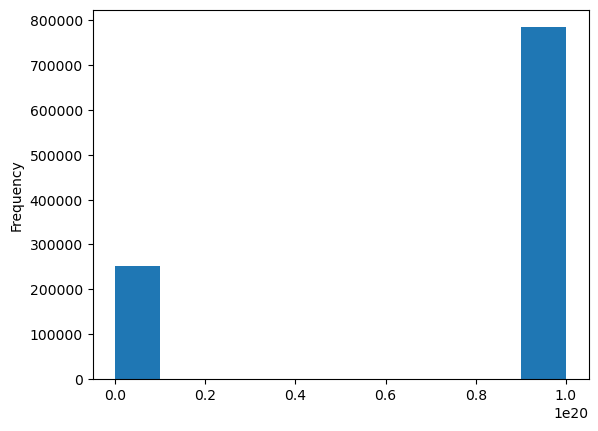

In [9]:
# TODO: remove nan values 1E20
dph["maxdph"].plot.hist()

# II. Power sector

## 1. Assets

In [ ]:
from src.helpers import read_csv_from_zip

In [11]:
zip_path = Path("../data/power.zip")
pat = "*_emissions_sources_v*.csv"
usecols = ["source_id", "iso3_country", "lat", "lon", "capacity"]
power = read_csv_from_zip(zip_path=zip_path, pat=pat, usecols=usecols)

Reading: DATA/electricity-generation_emissions_sources_v4_8_0.csv


In [12]:
expo_fpath = Path("../data/exposures/power.parquet")

In [13]:
# Uncomment to merge
power = gpd.GeoDataFrame(power, geometry=gpd.points_from_xy(power["lon"], power["lat"]), crs="EPSG:4326")
merged = gpd.sjoin_nearest(power.to_crs("EPSG:3857"), dph.to_crs("EPSG:3857"), max_distance=50_000, distance_col="dist")
# Drop geometry col to allow reading parquet from different interfaces
merged = merged.drop(columns=["geometry"]) #.rename(columns={"maxdph": "flood_depth_m"})
merged.to_parquet(expo_fpath, index=False)

In [14]:
# TODO: format and merge with damage function
expo = pd.read_parquet(expo_fpath)

In [15]:
dmg_fpath = Path("../data/copy_of_global_flood_depth-damage_functions__30102017.xlsx")
dmg = pd.read_excel(dmg_fpath, engine="calamine", sheet_name="Damage functions", header=[1, 2], na_values=["-"])

In [16]:

def melt_damage_table(dmg: pd.DataFrame) -> pd.DataFrame:
    """
    Melt a MultiIndex damage table from Excel into a tidy long format with relative damage and standard deviation.

    Args:
        dmg (pd.DataFrame): MultiIndex DataFrame with two-level columns, typically read from Excel:
            - Top-level: "Damage class", "Flood depth,[m]", "Damage function", "Standard deviation"
            - Second-level: region names or unnamed.

    Returns:
        pd.DataFrame: Melted DataFrame with columns:
            - damage_class (str)
            - flood_depth_m (float)
            - region (str)
            - rel_damage (float)
            - std (float)
    """
    # Extract and clean index columns
    index = dmg.loc[:, [
        ("Damage\r\nclass", "Unnamed: 0_level_1"), 
        ('Flood depth,\r\n[m]', "Unnamed: 1_level_1")
    ]]
    index.columns = index.columns.get_level_values(0)
    index = index.rename(columns={
        "Damage\r\nclass": "damage_class", 
        'Flood depth,\r\n[m]': "flood_depth_m"
    })
    index["damage_class"] = index["damage_class"].ffill()
    index.set_index(["damage_class", "flood_depth_m"], inplace=True)
    index = index.index  # save MultiIndex for alignment

    # Melt Damage function
    funcs = dmg.loc[:, "Damage function"]
    funcs.set_index(index, inplace=True)
    funcs_melt = funcs.reset_index().melt(
        id_vars=("damage_class", "flood_depth_m"),
        var_name="region",
        value_name="rel_damage"
    )

    # Melt Standard deviation
    stds = dmg.loc[:, "Standard deviation"]
    stds.set_index(index, inplace=True)
    stds_melt = stds.reset_index().melt(
        id_vars=("damage_class", "flood_depth_m"),
        var_name="region",
        value_name="std"
    )

    # Merge damage and standard deviation into one tidy DataFrame
    dmg_std_melt = pd.merge(
        funcs_melt, stds_melt, 
        how="left", 
        on=["damage_class", "flood_depth_m", "region"]
    )

    # Replace missing values "-" with nan
    # dmg_std_melt.replace("-", np.nan, inplace=True)
    return dmg_std_melt


In [17]:
dmg = melt_damage_table(dmg)

In [18]:
dmg["region"].unique()

array(['EUROPE', 'North AMERICA', 'Centr&South\r\nAMERICA', 'ASIA',
       'AFRICA', 'OCEANIA', 'GLOBAL'], dtype=object)

## Merge Power and damage

In [19]:
expo

,source_id,iso3_country,lat_left,lon_left,capacity,index_right,lon_right,lat_right,year,maxdph,dist
0,25452484,ABW,12.4759,-69.9823,254.5,317110,-69.923558,12.392211,1980,1.000000e+20,11565.922979
1,25452484,ABW,12.4759,-69.9823,254.5,317110,-69.923558,12.392211,1980,1.000000e+20,11565.922979
2,25452484,ABW,12.4759,-69.9823,254.5,317110,-69.923558,12.392211,1980,1.000000e+20,11565.922979
3,25452484,ABW,12.4759,-69.9823,254.5,317110,-69.923558,12.392211,1980,1.000000e+20,11565.922979
4,25452484,ABW,12.4759,-69.9823,254.5,317110,-69.923558,12.392211,1980,1.000000e+20,11565.922979
...,...,...,...,...,...,...,...,...,...,...,...
530987,25452552,ZWE,-18.6567,29.7810,100.0,604514,29.895761,-18.650904,1980,0.000000e+00,12793.266791
530988,25452552,ZWE,-18.6567,29.7810,100.0,604514,29.895761,-18.650904,1980,0.000000e+00,12793.266791
530989,25452552,ZWE,-18.6567,29.7810,100.0,604514,29.895761,-18.650904,1980,0.000000e+00,12793.266791
530990,25452552,ZWE,-18.6567,29.7810,100.0,604514,29.895761,-18.650904,1980,0.000000e+00,12793.266791


In [20]:
import country_converter as coco
#1.Instantiate country converter object
cc = coco.CountryConverter()  

In [21]:
expo["un_region"] = cc.pandas_convert(expo["iso3_country"], src="ISO3", to="UNregion")

ZNC not found in ISO3


In [22]:
import json
with open("../data/UNregion2huizinga.json", "r") as f:
    un2huizinga = json.load(f)

In [23]:
expo["region"] = expo["un_region"].map(un2huizinga)

In [24]:
power_dmg = dmg.loc[dmg["damage_class"] == "Industrial buildings"].reset_index().sort_values("flood_depth_m")
power_expo = pd.merge_asof(expo.sort_values("maxdph").astype({"maxdph": "float64"}), 
              power_dmg,
                left_on='maxdph',
                right_on='flood_depth_m',
                by='region',             # exact match on region
                direction='nearest'      # options: 'backward', 'forward', 'nearest'
)
power_expo = power_expo.assign(depth_diff=power_expo["maxdph"]-power_expo["flood_depth_m"],
                               capacity_loss=power_expo["capacity"] * power_expo["rel_damage"])

In [25]:
TableReport(power_expo)

Processing column  20 / 20


,,,,,,,,,,,,,,,,,,,,


In [ ]:
# TODO: include pangeo runoff

## 2. Ownership

In [29]:
own_pat = "*_emissions_sources_ownership_v*.csv"
# usecols = ["source_id", "parent_name", "overall_share_percent"]
own = read_csv_from_zip(zip_path=zip_path, pat=own_pat) #, usecols=usecols)

Reading: DATA/electricity-generation_emissions_sources_ownership_v4_8_0.csv


In [31]:
own.shape

(35571, 18)

In [ ]:
# TODO: merge is not working
pd.merge(power_expo, own, how="left", on="source_id")

,source_id,iso3_country,lat_left,lon_left,capacity,index_right,lon_right,lat_right,year,maxdph,...,region,index,damage_class,flood_depth_m,rel_damage,std,depth_diff,capacity_loss,parent_name,overall_share_percent
0,25450414,CZE,50.6444,13.9854,158.0,558157,13.884642,50.695410,1980,0.000000e+00,...,EUROPE,18.0,Industrial buildings,0.0,0.0,NaN,0.0,0.0,NaN,NaN
1,25454486,CZE,50.6462,13.9854,70.0,558157,13.884642,50.695410,1980,0.000000e+00,...,EUROPE,18.0,Industrial buildings,0.0,0.0,NaN,0.0,0.0,NaN,NaN
2,25454486,CZE,50.6462,13.9854,70.0,558157,13.884642,50.695410,1980,0.000000e+00,...,EUROPE,18.0,Industrial buildings,0.0,0.0,NaN,0.0,0.0,NaN,NaN
3,25454486,CZE,50.6462,13.9854,70.0,558157,13.884642,50.695410,1980,0.000000e+00,...,EUROPE,18.0,Industrial buildings,0.0,0.0,NaN,0.0,0.0,NaN,NaN
4,25454486,CZE,50.6462,13.9854,70.0,558157,13.884642,50.695410,1980,0.000000e+00,...,EUROPE,18.0,Industrial buildings,0.0,0.0,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2085379,25452484,ABW,12.4759,-69.9823,356.5,317110,-69.923558,12.392211,1980,1.000000e+20,...,Centr&South\r\nAMERICA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Utilities Aruba NV,100.0
2085380,25452484,ABW,12.4759,-69.9823,254.5,317110,-69.923558,12.392211,1980,1.000000e+20,...,Centr&South\r\nAMERICA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Government of Aruba,100.0
2085381,25452484,ABW,12.4759,-69.9823,254.5,317110,-69.923558,12.392211,1980,1.000000e+20,...,Centr&South\r\nAMERICA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Utilities Aruba NV,100.0
2085382,25452484,ABW,12.4759,-69.9823,356.5,317110,-69.923558,12.392211,1980,1.000000e+20,...,Centr&South\r\nAMERICA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Government of Aruba,100.0
